# Champion Win Rate Analyzer & Predictor
### Using Oracle's Elixir Public Match Data (2023–2025) — Tier 2 Leagues and Above

**Research Question:** Can we predict whether a champion will win a professional League of Legends game based on their historical win rate, role, and in-game performance stats?

**Target Variable:** `result` — 1 = Win, 0 = Loss (binary classification)

**League Filter:** Only Tier 2 leagues and above are included. Lower-tier regional leagues are excluded because they have smaller player pools, less consistent data coverage, and significantly different meta patterns compared to top-level professional play. Including them would dilute champion win rates with games that do not reflect high-level competitive norms.

**Note on Side Variable:** Blue/Red side is excluded from all analysis and ML features. Blue side wins approximately 52% of games due to draft order advantage — this is a structural property of the game format, not of individual champion strength.

---

**Contents:**
- Part 1: Import Libraries
- Part 2: Load Data
- Part 3: Exploratory Data Analysis
- Part 4: Feature Engineering & Preprocessing
- Part 5: Models
- Part 6: Evaluation
- Part 7: Champion Lookup Tools


# Part 1: Import Libraries

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn --quiet


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

BLUE  = '#3498db'
RED   = '#e74c3c'
GREEN = '#2ecc71'
GOLD  = '#f39c12'

print('Libraries imported.')


Libraries imported.


# Part 2: Load Data

In [3]:
# Load three yearly CSV files and combine into one DataFrame
data2023 = pd.read_csv('/Users/tamkhong/Downloads/DATA SCIENCE PROJECT 2/2023_LoL_esports_match_data_from_OraclesElixir.csv', low_memory=False)
data2024 = pd.read_csv('/Users/tamkhong/Downloads/DATA SCIENCE PROJECT 2/2024_LoL_esports_match_data_from_OraclesElixir.csv', low_memory=False)
data2025 = pd.read_csv('/Users/tamkhong/Downloads/DATA SCIENCE PROJECT 2/2025_LoL_esports_match_data_from_OraclesElixir.csv', low_memory=False)

df_raw = pd.concat([data2023, data2024, data2025], ignore_index=True)
print(f'Loaded {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')

#check missing values
missing_values = df_raw.isnull().sum()
print('Missing values per column:')


Loaded 376,452 rows x 165 columns
Missing values per column:


In [4]:
# Keep only player rows — team summary rows (position='team') have no champion data
# Each game has 10 player rows + 2 team rows; we only need the player rows
df = df_raw[df_raw['position'] != 'team'].copy()

# Remove rows with no champion name
df = df[df['champion'].notna() & (df['champion'] != '')].copy()

print(f'Player rows: {len(df):,}')
print(f'Unique champions: {df["champion"].nunique()}')


Player rows: 313,710
Unique champions: 172


In [5]:
# Filter to Tier 2 leagues and above
#
# Tier 1 — The four major international leagues:
#   LCK (Korea), LPL (China), LEC (Europe), LCS (North America)
#
# Tier 2 — Strong regional leagues with established competition:
#   CBLOL (Brazil), LLA (Latin America), VCS (Vietnam), PCS (Pacific),
#   LCO (Oceania), LJL (Japan), TCL (Turkey), LCL (CIS)
#
# International events (included — highest level of competition):
#   Worlds, MSI, All-Star
#
# Excluded: Tier 3 and below regional/amateur leagues
# Reason: smaller player pools, inconsistent data, different meta patterns

TIER2_AND_ABOVE = [
    # Tier 1 — Major leagues
    'LCK', 'LPL', 'LEC', 'LCS',
    # Tier 2 — Regional leagues
    'CBLOL', 'LLA', 'VCS', 'PCS',
    'LCO', 'LJL', 'TCL', 'LCL',
    'LCSA', 'NACL',
    # International tournaments
    'Worlds', 'MSI', 'All-Star',
]

before = len(df)
df = df[df['league'].isin(TIER2_AND_ABOVE)].copy()
after  = len(df)

print(f'Rows before league filter: {before:,}')
print(f'Rows after  league filter: {after:,}  ({before - after:,} rows removed)')
print()
print('Leagues kept and their game counts:')
league_counts = (
    df.groupby('league')
    .size()
    .reset_index(name='rows')
    .sort_values('rows', ascending=False)
)
# Approximate game count (each game = 10 player rows)
league_counts['approx_games'] = (league_counts['rows'] / 10).astype(int)
print(league_counts.to_string(index=False))
print()
print(f'Unique champions after filter: {df["champion"].nunique()}')


Rows before league filter: 313,710
Rows after  league filter: 112,490  (201,220 rows removed)

Leagues kept and their game counts:
league  rows  approx_games
   LPL 22770          2277
  NACL 16310          1631
   LCK 15250          1525
   PCS  8930           893
   LEC  8880           888
   LJL  7800           780
   VCS  7570           757
   TCL  6010           601
 CBLOL  5050           505
   LCS  4560           456
   LLA  4060           406
   LCO  2960           296
   MSI  2340           234

Unique champions after filter: 171


# Part 3: Exploratory Data Analysis

In [6]:
# Games per champion | champions with very few games have unreliable win rates
champ_counts = df['champion'].value_counts()
print(f'Unique champions: {len(champ_counts)}')
print('\nMost played:')
print(champ_counts.head(10).to_string())
print('\nLeast played (noisy win rates):')
print(champ_counts.tail(10).to_string())


Unique champions: 171

Most played:
champion
K'Sante     3686
Nautilus    3256
Rell        3025
Sejuani     2998
Rakan       2733
Varus       2694
Azir        2490
Vi          2444
Maokai      2404
Renekton    2390

Least played (noisy win rates):
champion
Evelynn      7
Singed       6
Shaco        5
Katarina     5
Rammus       5
Talon        4
Teemo        2
Master Yi    1
Fizz         1
Briar        1


In [7]:
# Minimum games threshold
# Champions with fewer than 20 games are excluded from win rate charts
# because sample sizes this small produce unreliable predictions and skew the visualizations.
MIN_GAMES = 20

qualified_champs = champ_counts[champ_counts >= MIN_GAMES].index.tolist()
print(f'Champions with >= {MIN_GAMES} games: {len(qualified_champs)}')
print(f'Champions excluded: {len(champ_counts) - len(qualified_champs)}')


Champions with >= 20 games: 155
Champions excluded: 16


In [8]:
# Roles available in the dataset
if 'position' in df.columns:
    print('Positions:')
    print(df['position'].value_counts())


Positions:
position
top    22498
jng    22498
mid    22498
bot    22498
sup    22498
Name: count, dtype: int64


In [9]:
# Overall win rates per champion
champ_wr = (
    df.groupby('champion')
    .agg(
        games    = ('result', 'count'),
        wins     = ('result', 'sum'),
        win_rate = ('result', 'mean'),
        avg_kills   = ('kills',  'mean'),
        avg_deaths  = ('deaths', 'mean'),
        avg_assists = ('assists','mean'),
    )
    .reset_index()
)
champ_wr['avg_kda'] = (champ_wr['avg_kills'] + champ_wr['avg_assists']) / champ_wr['avg_deaths'].clip(lower=1)

champ_wr_filtered = champ_wr[champ_wr['games'] >= MIN_GAMES].copy()
champ_wr_filtered = champ_wr_filtered.sort_values('win_rate', ascending=False)

print(f'Win rates computed for {len(champ_wr_filtered)} champions:')
print(champ_wr_filtered[['champion','games','wins','win_rate','avg_kda']].head(10).to_string(index=False))


Win rates computed for 155 champions:
      champion  games  wins  win_rate  avg_kda
        Akshan     23    15  0.652174 3.656250
    Tryndamere     34    22  0.647059 3.623529
           Vex     37    23  0.621622 3.007937
         Quinn     23    14  0.608696 2.320988
Nunu & Willump     20    12  0.600000 4.436364
     Dr. Mundo     60    36  0.600000 3.296053
         Garen     81    48  0.592593 2.671233
  Twisted Fate    408   240  0.588235 3.496894
   Mordekaiser    109    62  0.568807 2.128866
    Blitzcrank    415   235  0.566265 3.034367


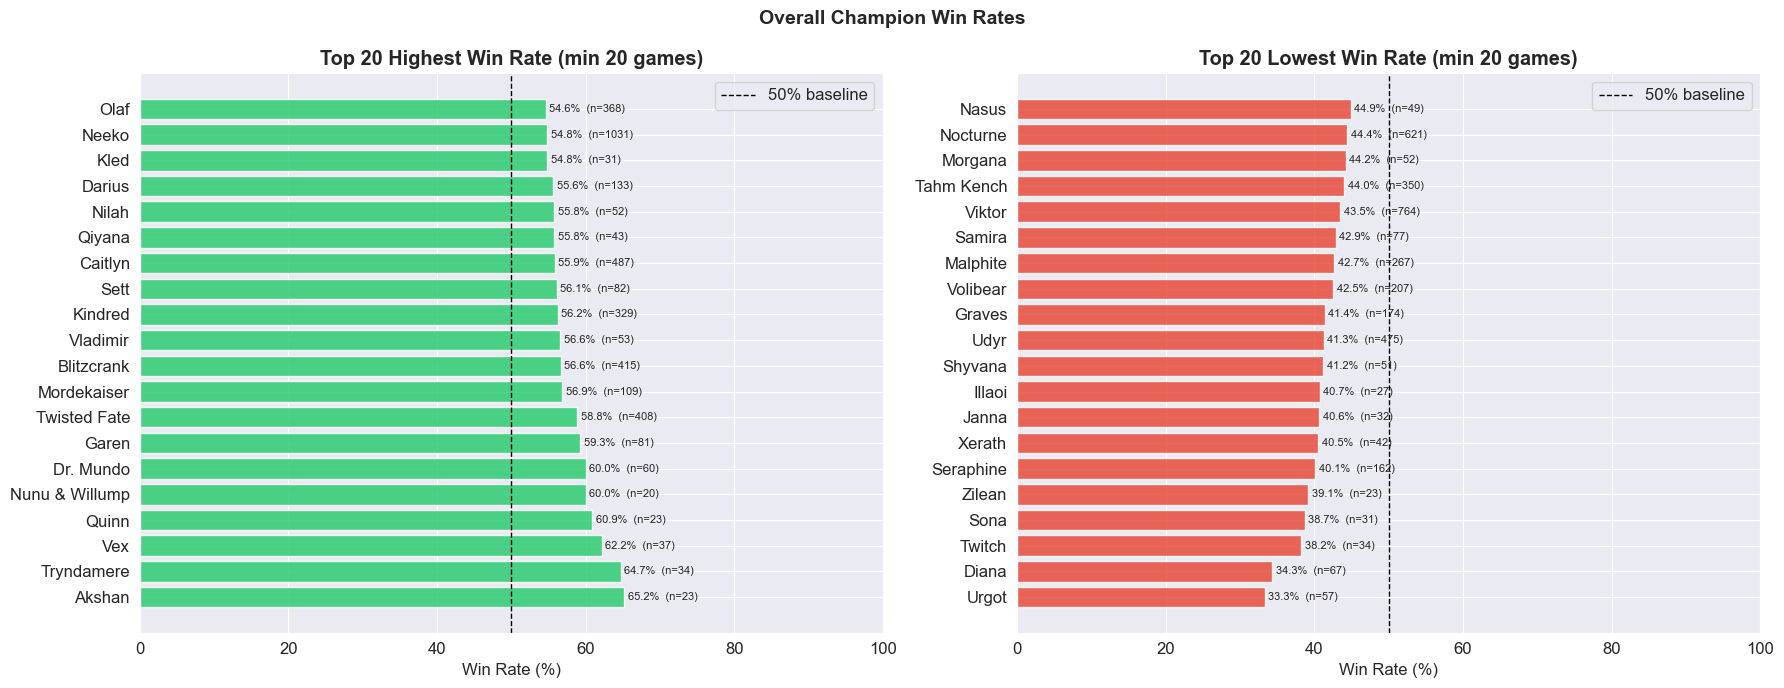

In [10]:
# Top 20 highest and lowest win rate champions
top20 = champ_wr_filtered.head(20)
bot20 = champ_wr_filtered.tail(20).sort_values('win_rate')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, data, title, color in [
    (axes[0], top20, f'Top 20 Highest Win Rate (min {MIN_GAMES} games)', GREEN),
    (axes[1], bot20, f'Top 20 Lowest Win Rate (min {MIN_GAMES} games)',  RED),
]:
    bars = ax.barh(data['champion'], data['win_rate'] * 100, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(50, color='black', linestyle='--', linewidth=1, label='50% baseline')
    ax.set_xlabel('Win Rate (%)')
    ax.set_title(title, fontweight='bold')
    ax.set_xlim(0, 100)
    for bar, (_, row) in zip(bars, data.iterrows()):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f"{row['win_rate']:.1%}  (n={int(row['games'])})", va='center', fontsize=8)
    ax.legend()
plt.suptitle('Overall Champion Win Rates', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [11]:
# Win rate by champion and role
# A champion's win rate is meaningless without knowing the role 
# For Example: Rumble top vs Rumble support are different picks
champ_role_wr = (
    df.groupby(['champion', 'position'])
    .agg(games=('result','count'), win_rate=('result','mean'))
    .reset_index()
)
champ_role_wr = champ_role_wr[champ_role_wr['games'] >= MIN_GAMES].copy()

print(f'Champion-role combinations with >= {MIN_GAMES} games: {len(champ_role_wr)}')
print(champ_role_wr.sort_values('win_rate', ascending=False).head(10).to_string(index=False))


Champion-role combinations with >= 20 games: 225
      champion position  games  win_rate
     Dr. Mundo      jng     27  0.629630
  Twisted Fate      top    245  0.628571
         Ziggs      mid     94  0.627660
           Zed      mid     29  0.620690
    Tryndamere      mid     21  0.619048
           Vex      mid     36  0.611111
         Quinn      top     23  0.608696
         Garen      top     73  0.602740
           Mel      mid     35  0.600000
Nunu & Willump      jng     20  0.600000


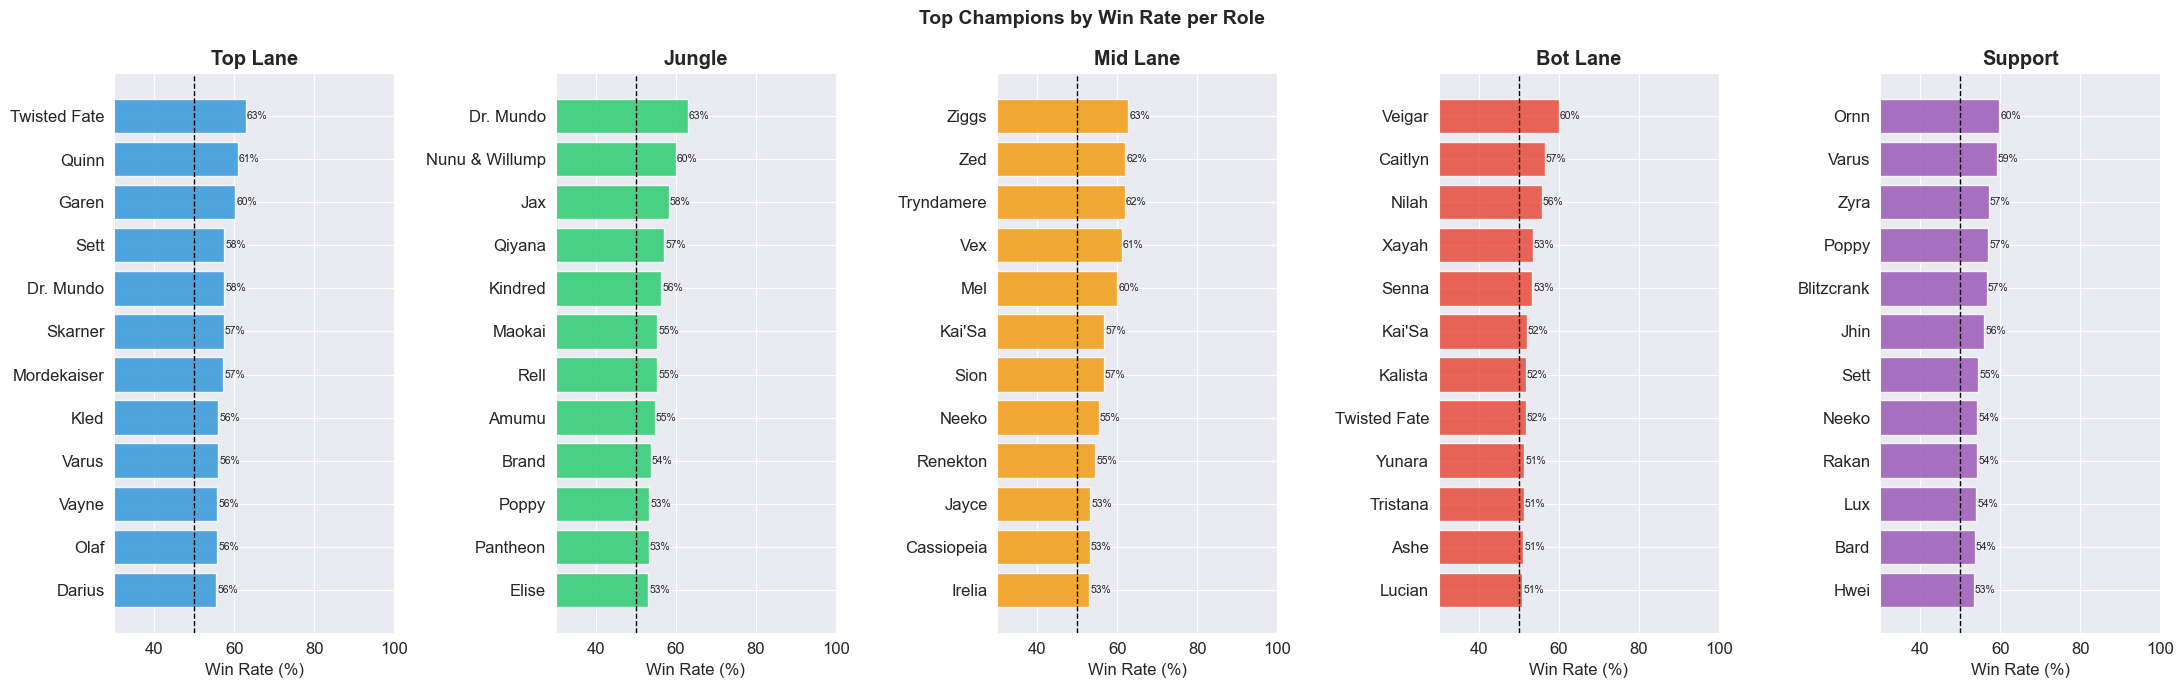

In [12]:
# Best champions per role
ROLES = ['top', 'jng', 'mid', 'bot', 'sup']
ROLE_LABELS = {'top':'Top Lane','jng':'Jungle','mid':'Mid Lane','bot':'Bot Lane','sup':'Support'}

fig, axes = plt.subplots(1, len(ROLES), figsize=(22, 7))
role_colors = [BLUE, GREEN, GOLD, RED, '#9b59b6']

for ax, role, color in zip(axes, ROLES, role_colors):
    role_data = (
        champ_role_wr[champ_role_wr['position'] == role]
        .sort_values('win_rate', ascending=True)
        .tail(12)
    )
    if len(role_data) == 0:
        ax.set_title(ROLE_LABELS.get(role, role))
        continue
    ax.barh(role_data['champion'], role_data['win_rate'] * 100, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(50, color='black', linestyle='--', linewidth=1)
    ax.set_xlim(30, 100)
    ax.set_xlabel('Win Rate (%)')
    ax.set_title(ROLE_LABELS.get(role, role), fontweight='bold')
    for i, (_, row) in enumerate(role_data.iterrows()):
        ax.text(row['win_rate'] * 100 + 0.3, i, f"{row['win_rate']:.0%}", va='center', fontsize=7.5)

plt.suptitle('Top Champions by Win Rate per Role', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [13]:
# Champion matchup win rates head-to-head in the same lane
# Join blue side player vs red side player in same game and position
if 'gameid' in df.columns and 'side' in df.columns:
    blue = df[df['side'] == 'Blue'][['gameid','position','champion','result']].copy()
    red  = df[df['side'] == 'Red' ][['gameid','position','champion','result']].copy()
    blue.columns = ['gameid','position','champion_blue','result_blue']
    red.columns  = ['gameid','position','champion_red', 'result_red']

    matchups = blue.merge(red, on=['gameid','position'], how='inner')

    a_vs_b = matchups[['champion_blue','champion_red','result_blue','position']].copy()
    a_vs_b.columns = ['champion','opponent','win','position']

    b_vs_a = matchups[['champion_red','champion_blue','result_blue','position']].copy()
    b_vs_a.columns = ['champion','opponent','win','position']
    b_vs_a['win'] = 1 - b_vs_a['win']

    all_matchups = pd.concat([a_vs_b, b_vs_a], ignore_index=True)
    matchup_wr = (
        all_matchups.groupby(['champion','opponent','position'])
        .agg(games=('win','count'), win_rate=('win','mean'))
        .reset_index()
    )
    matchup_wr = matchup_wr[matchup_wr['games'] >= 5]
    print(f'Matchup pairs built: {len(matchup_wr):,}')
    print(matchup_wr.sort_values('win_rate', ascending=False).head(10).to_string(index=False))
else:
    matchup_wr = pd.DataFrame()
    print('gameid or side column not found.')


Matchup pairs built: 2,704
    champion   opponent position  games  win_rate
        Jinx    Kog'Maw      bot      7       1.0
      Maokai        Jax      top      6       1.0
      Wukong   Volibear      jng      6       1.0
     Trundle    Skarner      jng      6       1.0
Twisted Fate      Jayce      top      9       1.0
      Darius    Camille      top      5       1.0
       Galio Cassiopeia      mid      5       1.0
   Dr. Mundo       Zyra      jng      5       1.0
   Jarvan IV   Volibear      jng      7       1.0
      Kai'Sa       Azir      mid      5       1.0


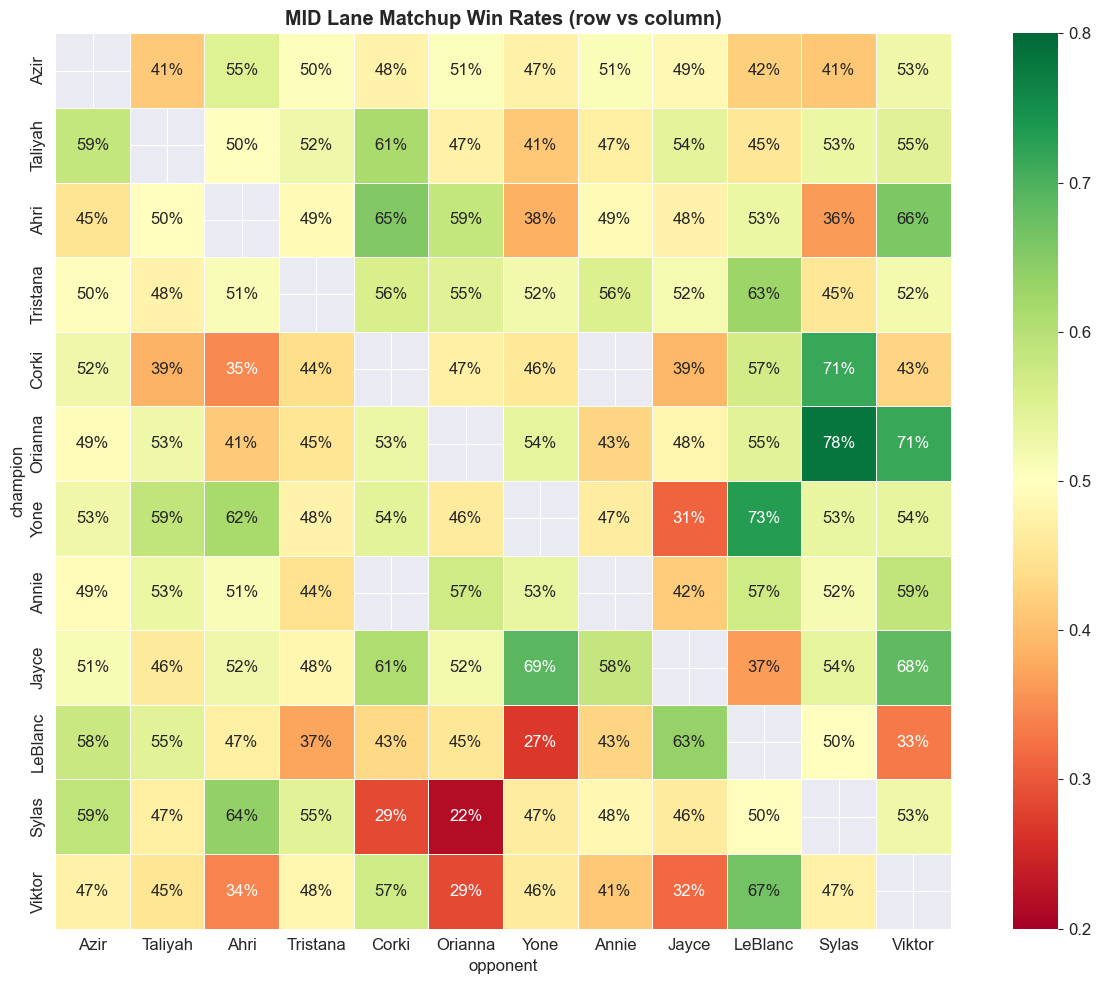

In [14]:
# Matchup heatmap for mid lane | who beats who?
MATCHUP_ROLE = 'mid'
TOP_N = 12

if len(matchup_wr) > 0:
    role_mu = matchup_wr[matchup_wr['position'] == MATCHUP_ROLE].copy()
    top_champs = role_mu.groupby('champion')['games'].sum().nlargest(TOP_N).index.tolist()
    heatmap_data = role_mu[
        role_mu['champion'].isin(top_champs) & role_mu['opponent'].isin(top_champs)
    ]
    pivot = heatmap_data.pivot_table(index='champion', columns='opponent', values='win_rate')
    pivot = pivot.reindex(index=top_champs, columns=top_champs)

    plt.figure(figsize=(13, 10))
    sns.heatmap(pivot, annot=True, fmt='.0%', cmap='RdYlGn', center=0.5,
                vmin=0.2, vmax=0.8, linewidths=0.5, square=True)
    plt.title(f'{MATCHUP_ROLE.upper()} Lane Matchup Win Rates (row vs column)', fontweight='bold')
    plt.tight_layout()
    plt.show()


# Part 4: Feature Engineering and Preprocessing

**Features selected (6 total):**

| Feature | Description |
|---|---|
| `champ_winrate` | Champion's overall historical win rate |
| `champ_role_winrate` | Champion's win rate in this specific role |
| `position_enc` | Role encoded as a number (top=0, jng=1, etc.) |
| `kills` | Player kills in this game |
| `deaths` | Player deaths in this game |
| `dpm` | Damage per minute — best single measure of combat output |

**Features excluded and why:**

| Excluded | Reason |
|---|---|
| `is_blue_side` | Blue side wins ~52% due to draft order, not champion strength |
| `champion_enc` | Numeric ID for a name carries no learnable signal |
| `earnedgold`, `damageshare`, `cspm`, `assists` | Correlated with `dpm` or `kills` — redundant |
| `patch_num` | Champion strength across patches is already captured by `champ_winrate` |


In [15]:
# Build ML feature set
df_ml = df.copy()
df_ml = df_ml[df_ml['champion'].notna() & df_ml['result'].notna()].copy()
df_ml['result'] = df_ml['result'].astype(int)

# Feature 1: Champion overall historical win rate
wr_map = champ_wr.set_index('champion')['win_rate'].to_dict()
df_ml['champ_winrate'] = df_ml['champion'].map(wr_map).fillna(0.5)

# Feature 2: Champion win rate in this specific role
role_wr_map = champ_role_wr.set_index(['champion','position'])['win_rate'].to_dict()
df_ml['champ_role_winrate'] = df_ml.apply(
    lambda r: role_wr_map.get((r['champion'], r.get('position','')), r['champ_winrate']), axis=1
)

# Feature 3: Role encoded as integer
le_pos = LabelEncoder()
df_ml['position_enc'] = le_pos.fit_transform(df_ml['position'].fillna('unknown'))

# Features 4-6: In-game performance stats
stat_features = []
for col in ['kills', 'deaths', 'dpm']:
    if col in df_ml.columns:
        df_ml[col] = pd.to_numeric(df_ml[col], errors='coerce')
        df_ml[col] = df_ml[col].fillna(df_ml[col].median())
        stat_features.append(col)

ML_FEATURES = ['champ_winrate', 'champ_role_winrate', 'position_enc'] + stat_features

print(f'Features ({len(ML_FEATURES)}): {ML_FEATURES}')
print(f'Total rows: {len(df_ml):,}')


Features (6): ['champ_winrate', 'champ_role_winrate', 'position_enc', 'kills', 'deaths', 'dpm']
Total rows: 112,490


In [16]:
# Train / Test Split
#
# Training data (80%) | the model learns patterns from these rows
# Test data    (20%) | held out; used ONLY to measure final accuracy
#
# stratify=y   ensures both splits have the same 50/50 win/loss balance
# random_state fixes the split so results are reproducible

X = df_ml[ML_FEATURES].fillna(0)
y = df_ml['result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features | StandardScaler transforms each feature to mean=0, std=1
# Fit ONLY on training data to prevent test information leaking into training
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training rows (model learns from these): {X_train.shape[0]:,}')
print(f'Test rows     (evaluate on these only):  {X_test.shape[0]:,}')
print(f'Win rate — train: {y_train.mean():.1%}  |  test: {y_test.mean():.1%}')


Training rows (model learns from these): 89,992
Test rows     (evaluate on these only):  22,498
Win rate — train: 50.0%  |  test: 50.0%


# Part 5: Models

Three classification models are trained and compared.

**Model 1: Logistic Regression**
Draws a weighted straight-line boundary between wins and losses. Each feature is assigned a coefficient positive pushes toward win, negative pushes toward loss. Chosen as the interpretable baseline: if a simple linear boundary achieves strong accuracy, no more complex model is needed. Limitation: assumes a linear relationship between features and outcome.

**Model 2: Random Forest**
Builds 200 decision trees independently, each trained on a random sample of the data. Every tree votes win or loss, and the majority wins. Chosen because it handles non-linear feature interactions automatically and provides feature importance scores. Limitation: less interpretable than Logistic Regression.

**Model 3: Gradient Boosting**
Builds 200 trees sequentially, each new tree is trained specifically to correct the mistakes of the previous ones. The low learning rate (0.05) means each tree only corrects a small portion of remaining error, reducing overfitting. Chosen because it typically achieves the highest accuracy on structured tabular data. Limitation: slowest to train; hardest to interpret.


In [17]:
# Train all three models on training data, evaluate on test data
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42),
}

results = {}
for name, model in models.items():
    print(f'Training {name}...', end=' ')
    model.fit(X_train_sc, y_train)          # learn from training data
    y_pred = model.predict(X_test_sc)       # predict on test data (never seen before)
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    results[name] = {'model': model, 'accuracy': acc, 'roc_auc': roc,
                     'y_pred': y_pred, 'y_prob': y_prob}
    print(f'Accuracy: {acc:.1%}  ROC-AUC: {roc:.3f}')

best_name = max(results, key=lambda n: results[n]['roc_auc'])
best = results[best_name]
print(f'\nBest model: {best_name}')


Training Logistic Regression... Accuracy: 77.8%  ROC-AUC: 0.855
Training Random Forest... Accuracy: 76.0%  ROC-AUC: 0.846
Training Gradient Boosting... Accuracy: 80.2%  ROC-AUC: 0.881

Best model: Gradient Boosting


# Part 6: Evaluation

In [18]:
# Summary table | all metrics computed on TEST data only
print('Model Comparison (Test Data):')
print(f'{"Model":<25} {"Accuracy":<12} {"ROC-AUC"}')
print('-' * 45)
for name, r in results.items():
    print(f'{name:<25} {r["accuracy"]:.1%}       {r["roc_auc"]:.3f}')

print(f'\nClassification Report — {best_name}:')
print(classification_report(y_test, best['y_pred'], target_names=['Loss', 'Win']))


Model Comparison (Test Data):
Model                     Accuracy     ROC-AUC
---------------------------------------------
Logistic Regression       77.8%       0.855
Random Forest             76.0%       0.846
Gradient Boosting         80.2%       0.881

Classification Report — Gradient Boosting:
              precision    recall  f1-score   support

        Loss       0.79      0.83      0.81     11250
         Win       0.82      0.78      0.80     11248

    accuracy                           0.80     22498
   macro avg       0.80      0.80      0.80     22498
weighted avg       0.80      0.80      0.80     22498



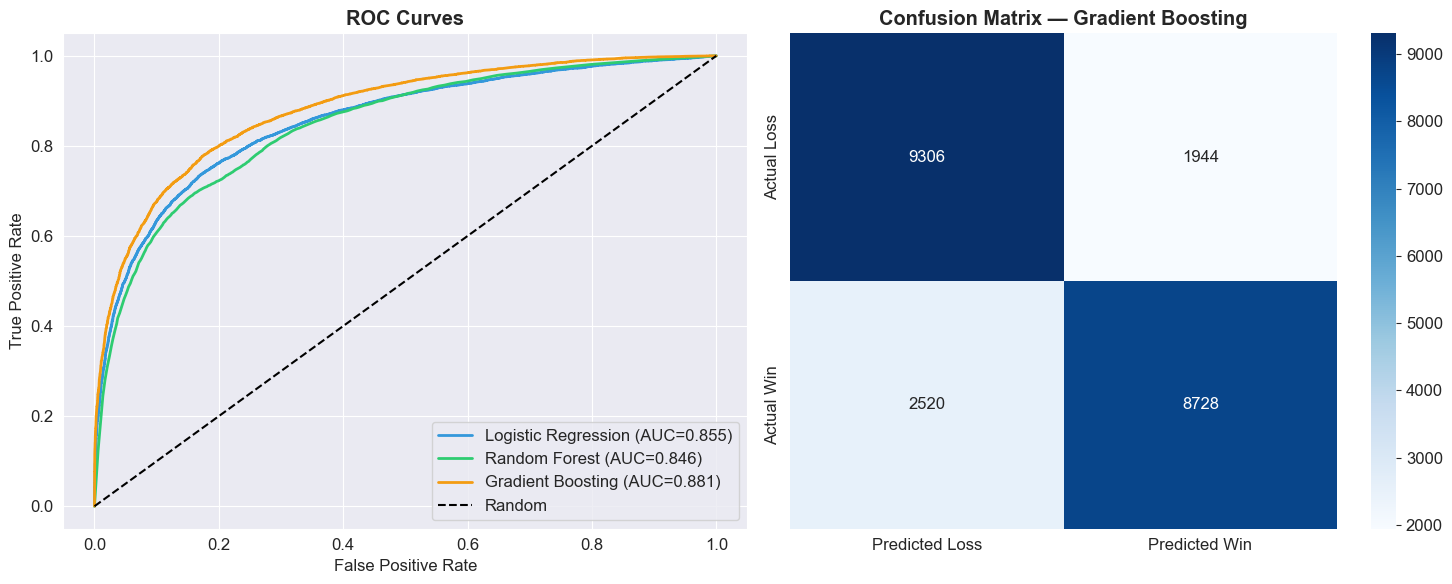

In [19]:
# ROC curves and confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for (name, r), color in zip(results.items(), [BLUE, GREEN, GOLD]):
    fpr, tpr, _ = roc_curve(y_test, r['y_prob'])
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={r['roc_auc']:.3f})")
axes[0].plot([0,1],[0,1],'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].legend()

cm = confusion_matrix(y_test, best['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Predicted Loss','Predicted Win'],
            yticklabels=['Actual Loss','Actual Win'])
axes[1].set_title(f'Confusion Matrix — {best_name}', fontweight='bold')

plt.tight_layout()
plt.show()


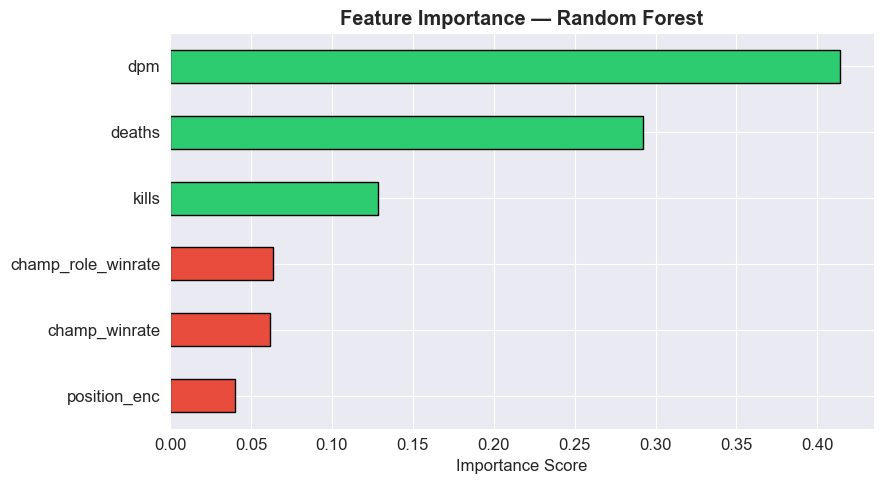

In [20]:
# Feature importance | which of the 6 features does the model rely on most?
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=ML_FEATURES).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
colors_imp = ['#e74c3c' if v < importances.median() else '#2ecc71' for v in importances]
importances.plot(kind='barh', color=colors_imp, edgecolor='black')
plt.title('Feature Importance — Random Forest', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


# Part 7: Champion Lookup Tools

Three functions for querying the results:
- `champion_winrate('Name')` — overall win rate, by role, by patch
- `matchup_winrate('Champ', 'Opponent', role='mid')` — head-to-head win rate
- `best_counter('Champ', 'mid')` — ranked list of counters


In [21]:
def _fuzzy_champ(name, champion_list):
    name_lower = name.lower()
    exact = [c for c in champion_list if c.lower() == name_lower]
    if exact:
        return exact[0]
    partial = [c for c in champion_list if name_lower in c.lower()]
    if len(partial) == 1:
        return partial[0]
    if len(partial) > 1:
        print(f'Multiple matches: {partial[:5]} — using "{partial[0]}"')
        return partial[0]
    return None

ALL_CHAMPS = df['champion'].dropna().unique().tolist()
PATCH_COL  = 'patch' if 'patch' in df.columns else ('split' if 'split' in df.columns else None)


def champion_winrate(champion_name):
    """Full win rate breakdown by role and patch. Usage: champion_winrate('Azir')"""
    champ = _fuzzy_champ(champion_name, ALL_CHAMPS)
    if champ is None:
        print(f'Champion "{champion_name}" not found.')
        return
    champ_df = df[df['champion'] == champ].copy()
    print(f'{champ} — Overall: {champ_df["result"].mean():.1%} ({len(champ_df)} games)')
    if 'position' in champ_df.columns:
        print('By role:')
        for role, grp in champ_df.groupby('position'):
            if len(grp) >= 3:
                print(f'  {role:<6}: {grp["result"].mean():.1%}  ({len(grp)} games)')
    if PATCH_COL and PATCH_COL in champ_df.columns:
        print(f'By {PATCH_COL}:')
        patch_stats = champ_df.groupby(PATCH_COL)['result'].agg(['count','mean'])
        for p, row in patch_stats[patch_stats['count'] >= 3].sort_index().iterrows():
            print(f'  {str(p):<10}: {row["mean"]:.1%}  ({int(row["count"])} games)')
    if all(c in champ_df.columns for c in ['kills','deaths','assists']):
        k, d, a = champ_df['kills'].mean(), champ_df['deaths'].mean(), champ_df['assists'].mean()
        print(f'Avg KDA: {k:.1f}/{d:.1f}/{a:.1f}  (KDA: {(k+a)/max(d,1):.2f})')


def matchup_winrate(champion, opponent, role=None):
    """Head-to-head win rate. Usage: matchup_winrate('Azir', 'Corki', role='mid')"""
    if len(matchup_wr) == 0:
        print('Matchup data not available.')
        return
    champ = _fuzzy_champ(champion, ALL_CHAMPS)
    opp   = _fuzzy_champ(opponent, ALL_CHAMPS)
    if not champ or not opp:
        return
    mask = (matchup_wr['champion'] == champ) & (matchup_wr['opponent'] == opp)
    if role:
        mask &= matchup_wr['position'] == role.lower()
    res = matchup_wr[mask]
    if len(res) == 0:
        print(f'No matchup data for {champ} vs {opp}' + (f' in {role}' if role else '') + '.')
        return
    print(f'{champ} vs {opp}:')
    for _, row in res.iterrows():
        verdict = 'FAVOURABLE' if row['win_rate'] >= 0.55 else 'UNFAVOURABLE' if row['win_rate'] <= 0.45 else 'EVEN'
        print(f'  {row["position"]}: {champ} {row["win_rate"]:.1%} | {opp} {1-row["win_rate"]:.1%} ({int(row["games"])} games) — {verdict}')


def best_counter(champion, role, top_n=10):
    """Best counters in a role. Usage: best_counter('Azir', 'mid')"""
    if len(matchup_wr) == 0:
        print('Matchup data not available.')
        return
    champ = _fuzzy_champ(champion, ALL_CHAMPS)
    if not champ:
        return
    counters = matchup_wr[
        (matchup_wr['opponent'] == champ) & (matchup_wr['position'] == role.lower())
    ].sort_values('win_rate', ascending=False).head(top_n)
    if len(counters) == 0:
        print(f'No counter data for {champ} in {role}.')
        return
    print(f'Best counters to {champ} in {role.upper()}:')
    for rank, (_, row) in enumerate(counters.iterrows(), 1):
        print(f'  {rank:2d}. {row["champion"]:<20} WR: {row["win_rate"]:.1%}  ({int(row["games"])} games)')
    fig, ax = plt.subplots(figsize=(9, max(4, len(counters) * 0.45)))
    ax.barh(counters['champion'], counters['win_rate'] * 100,
            color=[GREEN if v > 0.5 else RED for v in counters['win_rate']], edgecolor='white')
    ax.axvline(50, color='black', linestyle='--')
    ax.set_xlabel('Win Rate (%)')
    ax.set_title(f'Best Counters to {champ} in {role.upper()}', fontweight='bold')
    ax.set_xlim(30, 100)
    plt.tight_layout()
    plt.show()


print('Tools ready.')
print('  champion_winrate("Azir")')
print('  matchup_winrate("Azir", "Corki", role="mid")')
print('  best_counter("Azir", "mid")')


Tools ready.
  champion_winrate("Azir")
  matchup_winrate("Azir", "Corki", role="mid")
  best_counter("Azir", "mid")


In [22]:
champion_winrate('Yuumi')


Yuumi — Overall: 46.0% (337 games)
By role:
  sup   : 46.0%  (337 games)
By patch:
  13.01     : 48.1%  (154 games)
  13.1      : 53.1%  (32 games)
  13.11     : 46.2%  (117 games)
  13.12     : 28.6%  (7 games)
  14.06     : 33.3%  (3 games)
  15.04     : 33.3%  (3 games)
  15.09     : 66.7%  (3 games)
Avg KDA: 0.5/1.6/9.4  (KDA: 6.04)


In [23]:
matchup_winrate('Yone', 'Aatrox', role='top')


Yone vs Aatrox:
  top: Yone 51.6% | Aatrox 48.4% (31 games) — EVEN


Best counters to K'Sante in TOP:
   1. Pantheon             WR: 80.0%  (5 games)
   2. Twisted Fate         WR: 71.4%  (56 games)
   3. Shen                 WR: 71.4%  (7 games)
   4. Vayne                WR: 70.6%  (17 games)
   5. Yorick               WR: 68.8%  (16 games)
   6. Rek'Sai              WR: 66.7%  (9 games)
   7. Skarner              WR: 63.2%  (68 games)
   8. Ambessa              WR: 62.8%  (86 games)
   9. Dr. Mundo            WR: 62.5%  (8 games)
  10. Kennen               WR: 60.9%  (69 games)


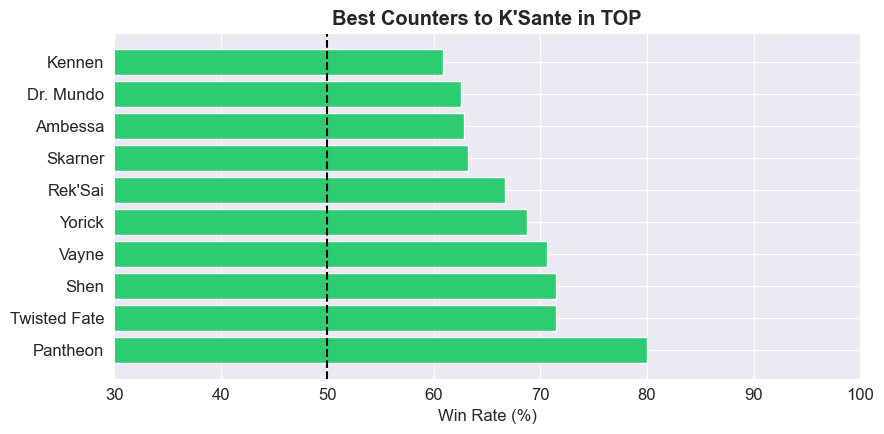

In [24]:
best_counter("K'Sante", 'top')


### Limitations:
### Patch changes are unpredictable. League of Legends is updated approximately every two weeks. A single patch can change a champion's win rate by 5 to 10 percentage points overnight through buffs, nerfs, or even changes to items that affect their strength. No historical model can anticipate these changes. A champion predicted to be strong in 2026 based on 2023–2025 data could be instantly weaker after a major balance update, and vice versa. This is the most significant limitation of any time-series prediction applied to a live-service game.
### No ban rate information. A champion with a 90% ban rate is almost certainly one of the strongest picks or no counter in the meta, yet its low appearance count produces a low or absent win rate in the dataset. The project has no look into ban data, meaning the most dominant champions in a given patch may be underrepresented or missing from the analysis entirely. 
### Regional bias picked. Data are gathered across all included leagues. A champion that is favored in one regional meta (for example, heavily favoured in the LCK but rarely played in the LCS) will have its win rate distorted or amplified by cross-regional effects not correlated to its true strength in any individual league. 
### Ethical:
### Data attribution and terms of use. This project uses data from Oracle’s Elixir and Leaguepedia, which come from Riot Games’ API. 
### Misuse of predictions for competitive advantage. Predictions based on historical win rates could help teams plan their drafts. But if teams rely only on this data and ignore the current patch, player skill on certain champions, or opponent habits, they might make bad choices. This model should be seen as an analyzing, not a decision.